# DSCI Analysis — Massachusetts

**DSCI (Drought Severity and Coverage Index)** is a single number in [0, 500] expressing weekly drought status for a state.

Formula: `DSCI = D0 + D1 + D2 + D3 + D4` (cumulative columns)

The **median/central curve** is found using Modified Band Depth (MBD2) — the most robust non-parametric depth measure for functional data (López-Pintado & Romo, 2009).

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm

## Configuration
Set your data file path and the year range you want to plot.

In [2]:
DATA_FILE  = "data.csv"   # path to your CSV file
STATE      = "MA"         # label used in the plot title

## Core Functions

In [3]:
def load_and_compute_dsci(path):
    """Load CSV and add DSCI, Year, Week columns."""
    df = pd.read_csv(path)
    df["MapDate"] = pd.to_datetime(df["MapDate"], format="%Y%m%d")
    df = df.sort_values("MapDate").reset_index(drop=True)
    df["DSCI"] = df["D0"] + df["D1"] + df["D2"] + df["D3"] + df["D4"]
    df["Year"] = df["MapDate"].dt.year
    df["Week"] = df["MapDate"].dt.isocalendar().week.astype(int)
    return df


def build_matrix(df, start_year, end_year, max_weeks=52):
    """Build a (n_years x 52) matrix, skipping incomplete or all-zero years."""
    df_range = df[(df["Year"] >= start_year) & (df["Year"] <= end_year)]
    years    = sorted(df_range["Year"].unique())
    matrix, valid_years = [], []

    for yr in years:
        ydf = df_range[(df_range["Year"] == yr) & (df_range["Week"] <= max_weeks)].sort_values("Week")
        if len(ydf) < max_weeks * 0.8:
            print(f"  Skipping {yr}: only {len(ydf)} weeks of data")
            continue
        if ydf["DSCI"].max() < 1.0:
            print(f"  Skipping {yr}: DSCI is all zero (missing/corrupt data)")
            continue
        curve = np.interp(
            np.arange(1, max_weeks + 1),
            ydf["Week"].values,
            ydf["DSCI"].values,
        )
        matrix.append(curve)
        valid_years.append(yr)

    return np.array(matrix), valid_years


def modified_band_depth(matrix):
    """Compute MBD2 for each curve. O(mn log n)."""
    n, m   = matrix.shape
    depths = np.zeros(n)
    denom  = m * (n * (n - 1) / 2)
    for j in range(m):
        col        = matrix[:, j]
        col_sorted = np.sort(col)
        for i, g in enumerate(col):
            a = np.searchsorted(col_sorted, g, side="left")
            c = n - np.searchsorted(col_sorted, g, side="right")
            b = n - a - c
            depths[i] += a * c + a * b + b * c + b * (b - 1) / 2
    return depths / denom


def plot_dsci(start_year, end_year, save_png=False):
    """
    Main entry point. Call this with a year range to produce the DSCI plot.

    Parameters
    ----------
    start_year : int   First year to include (e.g. 2001)
    end_year   : int   Last year to include  (e.g. 2024)
    save_png   : bool  If True, saves dsci_plot.png to the working directory
    """
    # --- load & filter ---
    df = load_and_compute_dsci(DATA_FILE)
    matrix, years = build_matrix(df, start_year, end_year)

    if len(years) == 0:
        print("No valid years found in that range.")
        return

    print(f"Years used : {years[0]}–{years[-1]}  ({len(years)} years)")

    # --- band depth ---
    print("Computing Modified Band Depth …")
    depths  = modified_band_depth(matrix)
    med_idx = int(np.argmax(depths))

    # --- plot ---
    n_years, n_weeks = matrix.shape
    weeks  = np.arange(1, n_weeks + 1)
    cmap   = matplotlib.colormaps.get_cmap("Blues").resampled(n_years + 6)
    colors = [cmap(i + 5) for i in range(n_years)]

    fig, ax = plt.subplots(figsize=(14, 6))

    for i, (curve, yr) in enumerate(zip(matrix, years)):
        is_med = (i == med_idx)
        ax.plot(
            weeks, curve,
            color     = "crimson" if is_med else colors[i],
            linewidth = 2.5 if is_med else 0.9,
            alpha     = 1.0 if is_med else 0.70,
            label     = f"Median curve — {yr} (MBD2)" if is_med else None,
            zorder    = 5 if is_med else 2,
        )

    sm = plt.cm.ScalarMappable(
        cmap="Blues", norm=plt.Normalize(vmin=years[0], vmax=years[-1]))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.01)
    cbar.set_label("Year", fontsize=11)

    ax.set_xlim(1, n_weeks)
    ax.set_ylim(-5, 505)
    ax.set_xlabel("Week of Year", fontsize=12)
    ax.set_ylabel("DSCI  [0 – 500]", fontsize=12)
    ax.set_title(
        f"Weekly DSCI — {STATE}  ({years[0]}–{years[-1]})\n"
        f"Red = deepest (most central) curve by Modified Band Depth  |  {n_years} years",
        fontsize=13,
    )
    ax.legend(fontsize=10)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()

    if save_png:
        fname = f"dsci_{STATE}_{years[0]}_{years[-1]}.png"
        plt.savefig(fname, dpi=150)
        print(f"Saved → {fname}")

    plt.show()

    # --- summary ---
    print("\nTop-5 most typical years (deepest MBD2):")
    for rank, idx in enumerate(np.argsort(depths)[::-1][:5], 1):
        print(f"  {rank}. {years[idx]}  (MBD2 = {depths[idx]:.4f})")
    print(f"\nMost anomalous year : {years[int(np.argmin(depths))]}  (MBD2 = {depths.min():.4f})")

## Run the Analysis

Call `plot_dsci(start_year, end_year)` with any range inside your dataset.

Set `save_png=True` to also write a `.png` file to disk.

  Skipping 2003: DSCI is all zero (missing/corrupt data)
  Skipping 2011: DSCI is all zero (missing/corrupt data)
Years used : 2001–2025  (23 years)
Computing Modified Band Depth …


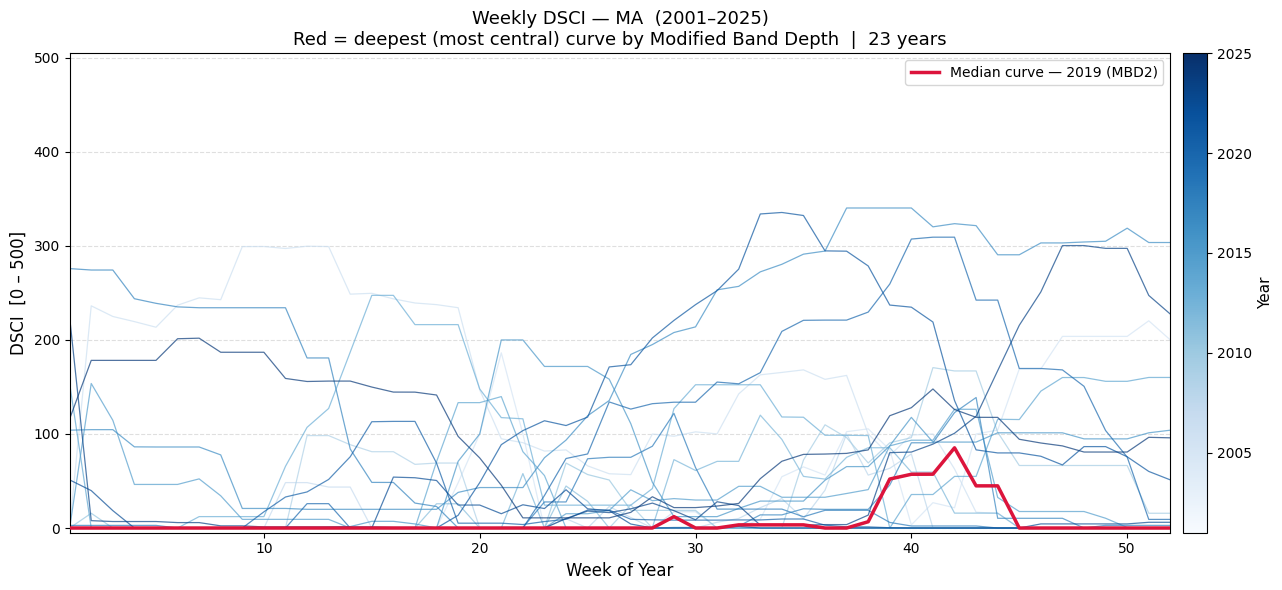


Top-5 most typical years (deepest MBD2):
  1. 2019  (MBD2 = 0.7185)
  2. 2005  (MBD2 = 0.7184)
  3. 2009  (MBD2 = 0.6988)
  4. 2008  (MBD2 = 0.6960)
  5. 2010  (MBD2 = 0.6954)

Most anomalous year : 2016  (MBD2 = 0.2549)


In [4]:
plot_dsci(2001, 2025)

Years used : 2015–2025  (11 years)
Computing Modified Band Depth …


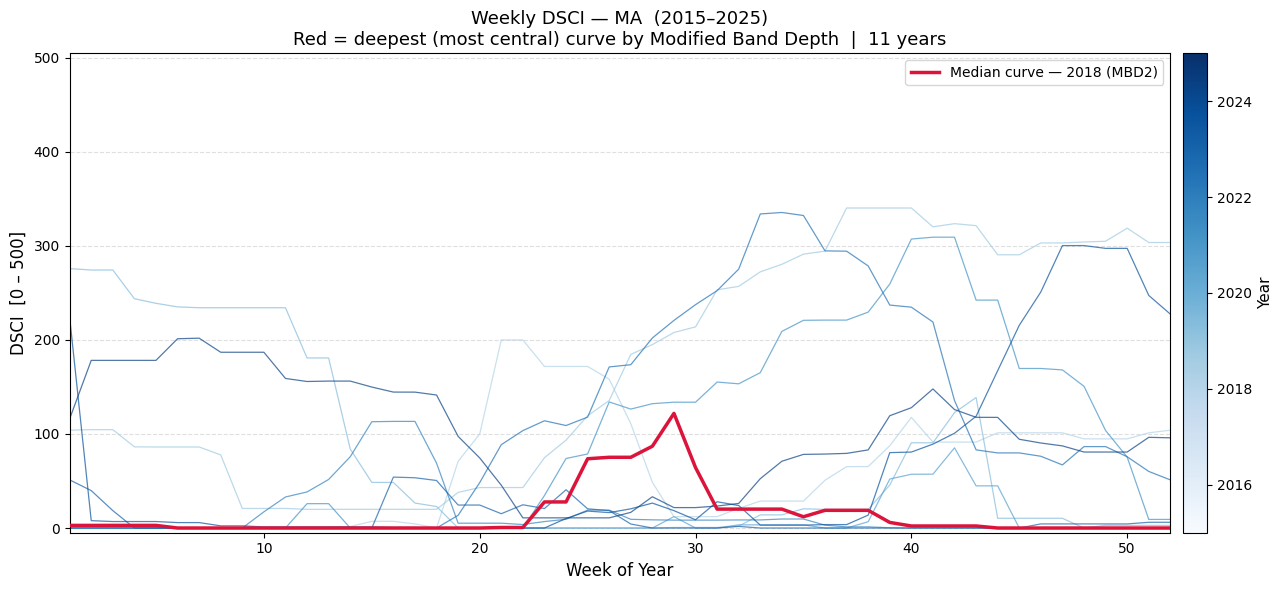


Top-5 most typical years (deepest MBD2):
  1. 2018  (MBD2 = 0.6255)
  2. 2019  (MBD2 = 0.5906)
  3. 2015  (MBD2 = 0.5895)
  4. 2020  (MBD2 = 0.5850)
  5. 2021  (MBD2 = 0.5524)

Most anomalous year : 2016  (MBD2 = 0.3745)


In [5]:
# Try a different range — e.g. last 10 years only
plot_dsci(2015, 2025)

Years used : 2020–2025  (6 years)
Computing Modified Band Depth …
Saved → dsci_MA_2020_2025.png


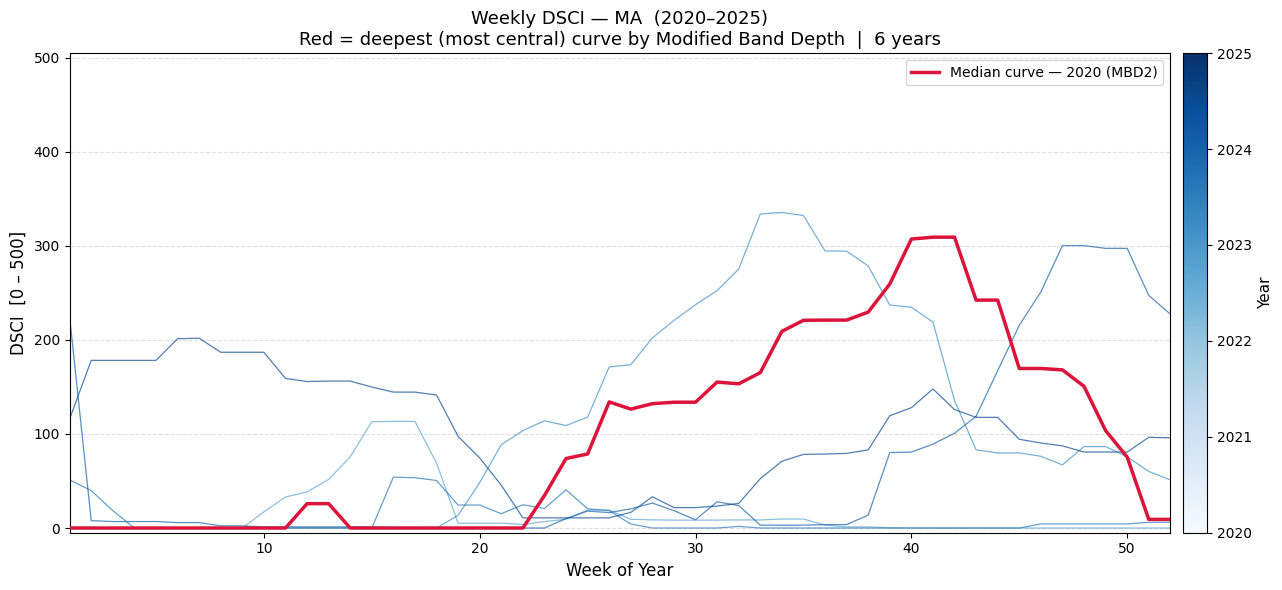


Top-5 most typical years (deepest MBD2):
  1. 2020  (MBD2 = 0.6513)
  2. 2021  (MBD2 = 0.6321)
  3. 2023  (MBD2 = 0.6128)
  4. 2024  (MBD2 = 0.6115)
  5. 2022  (MBD2 = 0.6051)

Most anomalous year : 2025  (MBD2 = 0.5590)


In [7]:
# Save to PNG as well
plot_dsci(2020, 2025, save_png=True)

Years used : 2012–2022  (11 years)
Computing Modified Band Depth …
Saved → dsci_MA_2012_2022.png


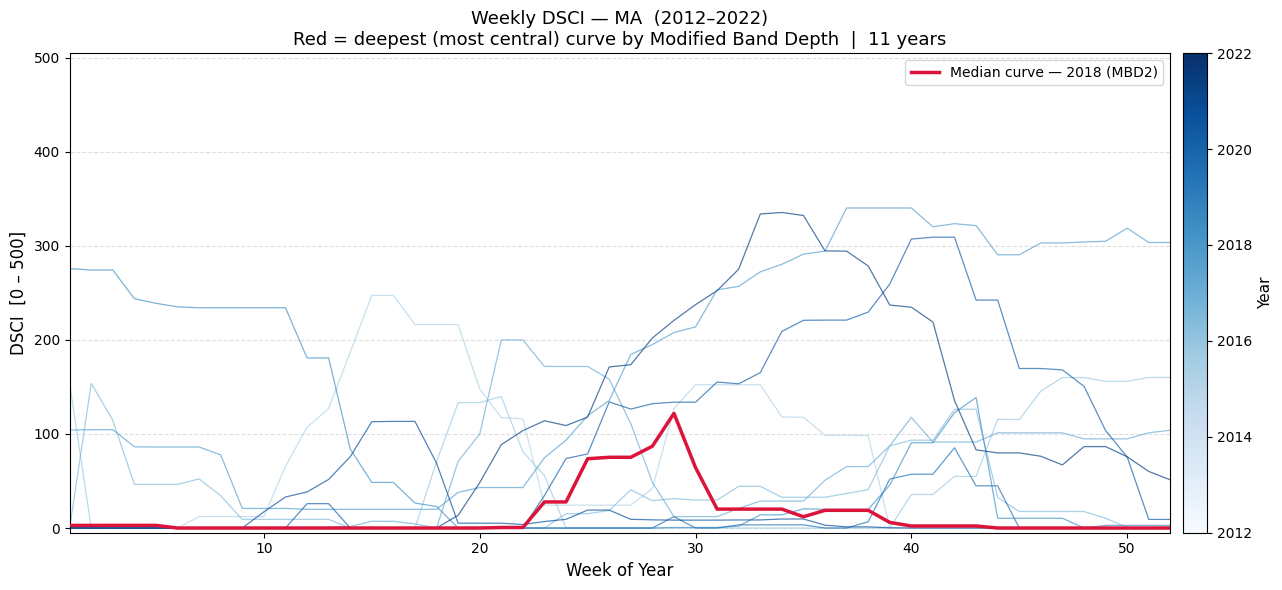


Top-5 most typical years (deepest MBD2):
  1. 2018  (MBD2 = 0.6514)
  2. 2019  (MBD2 = 0.6437)
  3. 2014  (MBD2 = 0.6185)
  4. 2015  (MBD2 = 0.6077)
  5. 2020  (MBD2 = 0.6038)

Most anomalous year : 2016  (MBD2 = 0.3601)


In [8]:
# Save to PNG as well
plot_dsci(2012, 2022, save_png=True)